In [86]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import warnings
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import random
warnings.filterwarnings("ignore")

In [87]:
# Устройство и количество GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f"Using device: {device}")
print(f"Number of available GPUs: {num_gpus}")

# Проверка памяти на всех GPU
for i in range(num_gpus):
    free_mem = torch.cuda.mem_get_info(i)[0] / 1024**3
    print(f"GPU {i} free memory: {free_mem:.2f} GB")

Using device: cuda
Number of available GPUs: 2
GPU 0 free memory: 13.84 GB
GPU 1 free memory: 14.37 GB


In [88]:
def train_epoch(train_generator, model, loss_function, optimizer, scaler, epoch,
                accumulation_steps=1, callback=None):
    model.train()
    epoch_loss = 0
    total_samples = 0
    optimizer.zero_grad()

    with tqdm(enumerate(train_generator), total=len(train_generator), desc=f"Epoch {epoch+1}", position=0, leave=True) as pbar:
        for i, (x_batch, y_batch) in pbar:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
    
            with autocast():
                output = model(x_batch)
                loss = loss_function(output, y_batch)
    
            loss = loss / accumulation_steps
            scaler.scale(loss).backward()
    
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
    
            batch_loss_val = loss.item() * accumulation_steps
            if callback is not None:
                with torch.no_grad():
                    callback(model, batch_loss_val)
    
            epoch_loss += batch_loss_val * len(x_batch)
            total_samples += len(x_batch)

            pbar.update(1)
            pbar.set_postfix(loss=loss.item())

    if total_samples % accumulation_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    return epoch_loss / total_samples

def trainer(count_of_epoch, batch_size, dataset, model, loss_function,
            optimizer, lr=0.001, accumulation_steps=1, callback=None):
    optima = optimizer(model.parameters(), lr=lr)
    scaler = GradScaler()
    iterations = tqdm(range(count_of_epoch), desc='epoch')
    iterations.set_postfix({'train epoch loss': np.nan})

    for i, it in enumerate(iterations):
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                                num_workers=2, pin_memory=True, drop_last=False)
        batch_generator = tqdm(dataloader, leave=False, total=len(dataloader), disable=True)

        epoch_loss = train_epoch(
            train_generator=batch_generator,
            model=model,
            loss_function=loss_function,
            optimizer=optima,
            scaler=scaler,
            epoch = i,
            accumulation_steps=accumulation_steps,
            callback=callback
        )
        iterations.set_postfix({'train epoch loss': epoch_loss})
        torch.cuda.empty_cache()

        # Сохранение (учитываем DataParallel)
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), f"unet_binarization_{i}.pth")
        else:
            torch.save(model.state_dict(), f"unet_binarization_{i}.pth")

RandomRotate90 - https://albumentations.ai/docs/api-reference/albumentations/augmentations/geometric/rotate/  
ShiftScaleRotate - https://albumentations.ai/docs/api-reference/albumentations/augmentations/geometric/transforms/

In [89]:
def add_background_artifacts(image, mask, num_shapes=random.randint(1, 3)):
    h, w = image.shape[:2]
    result = image.copy()

    # 1. текст (чёрный)
    text_mask = (mask < 100).astype(np.uint8)

    coords = np.column_stack(np.where(text_mask > 0))
    if len(coords) == 0:
        return result

    # 2. bbox текста
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    # 3. расширяем bbox (чтобы не лезло к тексту)
    pad = (h + w) // 20
    x_min = max(0, x_min - pad)
    x_max = min(w, x_max + pad)
    y_min = max(0, y_min - pad)
    y_max = min(h, y_max + pad)

    # 4. маска "разрешённых зон" = вне страницы
    allowed = np.ones((h, w), dtype=np.uint8)
    allowed[y_min:y_max, x_min:x_max] = 0

    for _ in range(num_shapes):
        shape_type = random.choice(["circle", "rectangle"])
        color = random.randint(0, 100)

        if shape_type == "circle":
            r = random.randint((h + w) // 50, 500)

            for _ in range(100):
                if r < w - r - 1 and r < h - r - 1:
                    x = random.randint(r, w - r - 1)
                    y = random.randint(r, h - r - 1)
                else:
                    continue

                y1, y2 = y - r, y + r + 1
                x1, x2 = x - r, x + r + 1

                patch = allowed[y1:y2, x1:x2]
                
                if r < patch.size == 0:
                    continue

                yy, xx = np.ogrid[-r:r+1, -r:r+1]
                circle_mask = (xx * xx + yy * yy) <= r * r

                if patch.shape == circle_mask.shape and np.all(patch[circle_mask] == 1):
                    cv2.circle(result, (x, y), r, (color, color, color), -1)
                    break

        else:
            rect_w = random.randint((h + w) // 50, (h + w) // 30)
            rect_h = random.randint((h + w) // 50, (h + w) // 30)

            for _ in range(100):
                x1 = random.randint(0, w - rect_w - 1)
                y1 = random.randint(0, h - rect_h - 1)
                x2 = x1 + rect_w
                y2 = y1 + rect_h

                patch = allowed[y1:y2, x1:x2]
                if patch.size == 0:
                    continue

                if np.all(patch == 1):
                    result[y1:y2, x1:x2] = (color, color, color)
                    break

    return result

def replace_background(image, mask, table_images):
    h, w = image.shape[:2]

    table_path = random.choice(table_images)
    table = cv2.imread(table_path)
    table = cv2.resize(table, (w, h))

    if len(image.shape) == 2:
        table = cv2.cvtColor(table, cv2.COLOR_BGR2GRAY)

    alpha = random.uniform(0.6, 0.9)
    table = (table * alpha).astype(np.uint8)

    text_mask = (mask < 127).astype(np.uint8)
    coords = np.column_stack(np.where(text_mask > 0))

    if len(coords) == 0:
        return image

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    pad = (h + w) // 20
    y_min = max(0, y_min - pad)
    y_max = min(h, y_max + pad)
    x_min = max(0, x_min - pad)
    x_max = min(w, x_max + pad)

    page_mask = np.zeros_like(mask, dtype=np.uint8)
    page_mask[y_min:y_max, x_min:x_max] = 1

    kernel = np.ones((7, 7), np.uint8)
    page_mask = cv2.dilate(page_mask, kernel)

    page_mask = page_mask.astype(bool)

    result = table.copy()
    result[page_mask] = image[page_mask]

    return result

class BinarizationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, target_size=(1024, 1024), augment=True, filenames=None,
                params_step_1 = {"Affine + HorizontalFlip" : 0.6, "RandomRotate90 + HorizontalFlip" : 0.4},
                params_step_2 = {"All image" : 0.4, "Divide into 4 squares" : 0.5, "All image + Divide into 4 squares" : 0.1}):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.target_size = target_size
        self.augment = augment

        self.params_step_1 = params_step_1
        self.params_step_2 = params_step_2

        if filenames is not None:
            self.filenames = filenames
        else:
            self.filenames = [
                f for f in os.listdir(images_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG'))
            ]

        self.table_images = [
            os.path.join("/kaggle/input/datasets/bobrzol123/dataset-table/dataset_table", f)
            for f in os.listdir("/kaggle/input/datasets/bobrzol123/dataset-table/dataset_table")
        ]

        if augment:
            self.geometric = A.Compose([
                A.OneOf([
                    A.Compose([
                        A.RandomRotate90(p=1),
                        A.HorizontalFlip(p=0.5)
                    ], p=self.params_step_1['RandomRotate90 + HorizontalFlip']),
                    A.Compose([
                        A.ShiftScaleRotate(
                            shift_limit=(-0.0625, 0.0625),
                            scale_limit=(-0.1, 0.1),
                            rotate_limit=(-30, 30),
                            border_mode=cv2.BORDER_CONSTANT,
                            fill=255,
                            fill_mask=255,
                            p=1
                        ),
                        A.HorizontalFlip(p=0.5)
                    ], p=self.params_step_1['Affine + HorizontalFlip'])
                ], p=1),
                A.LongestMaxSize(
                    max_size=max(target_size),
                    interpolation=1,
                    mask_interpolation=0
                ),
                A.PadIfNeeded(
                    min_height=target_size[0],
                    min_width=target_size[1],
                    border_mode=cv2.BORDER_CONSTANT,
                    fill=255,
                    fill_mask=255
                )
            ], p=1)
        else:
            self.geometric = None

        self.resizer = A.Compose([
            A.LongestMaxSize(
                max_size=max(target_size),
                interpolation=1,
                mask_interpolation=0
            ),
            A.PadIfNeeded(
                min_height=target_size[0],
                min_width=target_size[1],
                border_mode=cv2.BORDER_CONSTANT,
                fill=255,
                fill_mask=255
            )
        ], p=1)

        if augment:     
            all_image = A.Compose([
                A.OneOf([
                    A.RandomShadow(
                        shadow_roi=(0, 0, 1, 1),
                        num_shadows_limit=(1, 1),
                        shadow_dimension=6,
                        shadow_intensity_range=(0.03, 0.08),
                    ),
                    A.RandomShadow(
                        shadow_roi=(0, 0, 1, 1),
                        num_shadows_limit=(1, 1),
                        shadow_dimension=3,
                        shadow_intensity_range=(0.05, 0.15),
                    ),
                    A.RandomSunFlare(
                        flare_roi=(0, 0, 1, 1),
                        src_radius=120,
                        src_color=(200, 200, 200),
                    ),
                    A.RandomBrightnessContrast(
                        brightness_limit=(-0.2, 0.2),
                        contrast_limit=(-0.2, 0.2),
                        brightness_by_max=False,
                    ),
                    A.Defocus(
                        radius=(3, 5),
                        alias_blur=(0.02, 0.1),
                    ),
                ], p=1.0)
            ], p=1.0)

            squares = [(0, 0, 0.5, 0.5), (0.5, 0, 1, 0.5), (0, 0.5, 0.5, 1), (0.5, 0.5, 1, 1)]
            transforms_squares_list = []
            for roi in squares:
                transforms_squares_list.append(A.RandomShadow(
                    shadow_roi=roi,
                    num_shadows_limit=(1, 1),
                    shadow_dimension=5,
                    shadow_intensity_range=(0.01, 0.07),
                    p=1,
                ))
                transforms_squares_list.append(A.RandomSunFlare(
                    flare_roi=roi,
                    src_radius=100,
                    src_color=(200, 200, 200),
                    p=1,
                ))
                transforms_squares_list.append(A.Defocus(radius=(3, 5), alias_blur=(0.02, 0.08), p=1.0))

            transforms_squares = A.OneOf(
                [A.SomeOf(transforms_squares_list, n=1, p=1)] * 5 +
                [A.SomeOf(transforms_squares_list, n=2, p=1)] * 3 +
                [A.SomeOf(transforms_squares_list, n=3, p=1)] * 2,
                p=1
            )

            self.shadow_transforms = A.OneOf([
                A.Compose([
                    all_image
                ], p=self.params_step_2['All image']),
                A.Compose([
                    transforms_squares
                ], p=self.params_step_2['Divide into 4 squares']),
                A.Compose([
                    transforms_squares,
                    all_image
                ], p=self.params_step_2['All image + Divide into 4 squares']),
            ], p=1)
        else:
            self.shadow_transforms = None

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        img_path = os.path.join(self.images_dir, img_name)

        mask_name = os.path.splitext(img_name)[0] + '.png'
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if image is None or mask is None:
            raise FileNotFoundError(f"Не удалось загрузить {img_path} или {mask_path}")

        if self.geometric is not None:
            augmented = self.geometric(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']
        else:
            resized = self.resizer(image=image, mask=mask)
            image, mask = resized['image'], resized['mask']

        if self.shadow_transforms is not None:
            augmented_img = self.shadow_transforms(image=image)
            image = augmented_img['image']

        if self.augment:
            if random.random() < 0.6:
                image = replace_background(image, mask, self.table_images)
        
            if random.random() < 0.6:
                image = add_background_artifacts(image, mask)

        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        image = image.astype(np.float32) / 255.0
        image = (image - 0.5) / 0.5 # -1 - чёрный 1 -белый

        mask = mask.astype(np.float32) / 255.0

        image_tensor = torch.from_numpy(image).unsqueeze(0)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)

        return image_tensor, mask_tensor

In [90]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.mp = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.mp(x))

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch//2, 2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                    diffY // 2, diffY - diffY // 2])
        return self.conv(torch.cat([x2, x1], dim=1))

class UNetTiny(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.inc = DoubleConv(in_channels, 4)
        
        self.down1 = Down(4, 8)
        self.down2 = Down(8, 16)
        self.down3 = Down(16, 32)
        
        self.up1 = Up(32, 16)
        self.up2 = Up(16, 8)
        self.up3 = Up(8, 4)
        
        self.outc = nn.Conv2d(4, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)
        return self.outc(x)

In [91]:
class UNetCallback:
    def __init__(self, writer, dataset, loss_function, delimiter=100, batch_size=2):
        self.step = 0
        self.writer = writer
        self.delimiter = delimiter
        self.loss_function = loss_function
        self.batch_size = batch_size
        self.dataset = dataset

    def forward(self, model, loss):
        self.step += 1
        self.writer.add_scalar('LOSS/train', loss, self.step)

        if self.step % self.delimiter == 0:
            dataloader = DataLoader(self.dataset, batch_size=self.batch_size, shuffle=True)
            model.eval()
            test_loss = 0
            total = 0

            with torch.no_grad():
                for i, (x_batch, y_batch) in enumerate(dataloader):
                    x_batch = x_batch.to(device)
                    y_batch = y_batch.to(device)

                    with autocast():
                        output = model(x_batch)
                        loss_val = self.loss_function(output, y_batch).item()

                    test_loss += loss_val * len(x_batch)
                    total += len(x_batch)

                    if i == 0:
                        n = min(4, x_batch.size(0))
                        fig, axes = plt.subplots(3, n, figsize=(n*2, 6))
                        for j in range(n):
                            axes[0, j].imshow(x_batch[j, 0].cpu(), cmap='gray')
                            axes[0, j].set_title('Input')
                            axes[0, j].axis('off')

                            pred = torch.sigmoid(output[j, 0]).cpu()
                            axes[1, j].imshow(pred, cmap='gray')
                            axes[1, j].set_title('Pred')
                            axes[1, j].axis('off')

                            axes[2, j].imshow(y_batch[j, 0].cpu(), cmap='gray')
                            axes[2, j].set_title('GT')
                            axes[2, j].axis('off')

                        self.writer.add_figure('VISUAL/predictions', fig, self.step)
                        plt.close(fig)
                        break

                test_loss /= total
                self.writer.add_scalar('LOSS/test', test_loss, self.step)
            model.train()

    def __call__(self, model, loss):
        self.forward(model, loss)

## Кусок кода для показа как проходит аугментаци:

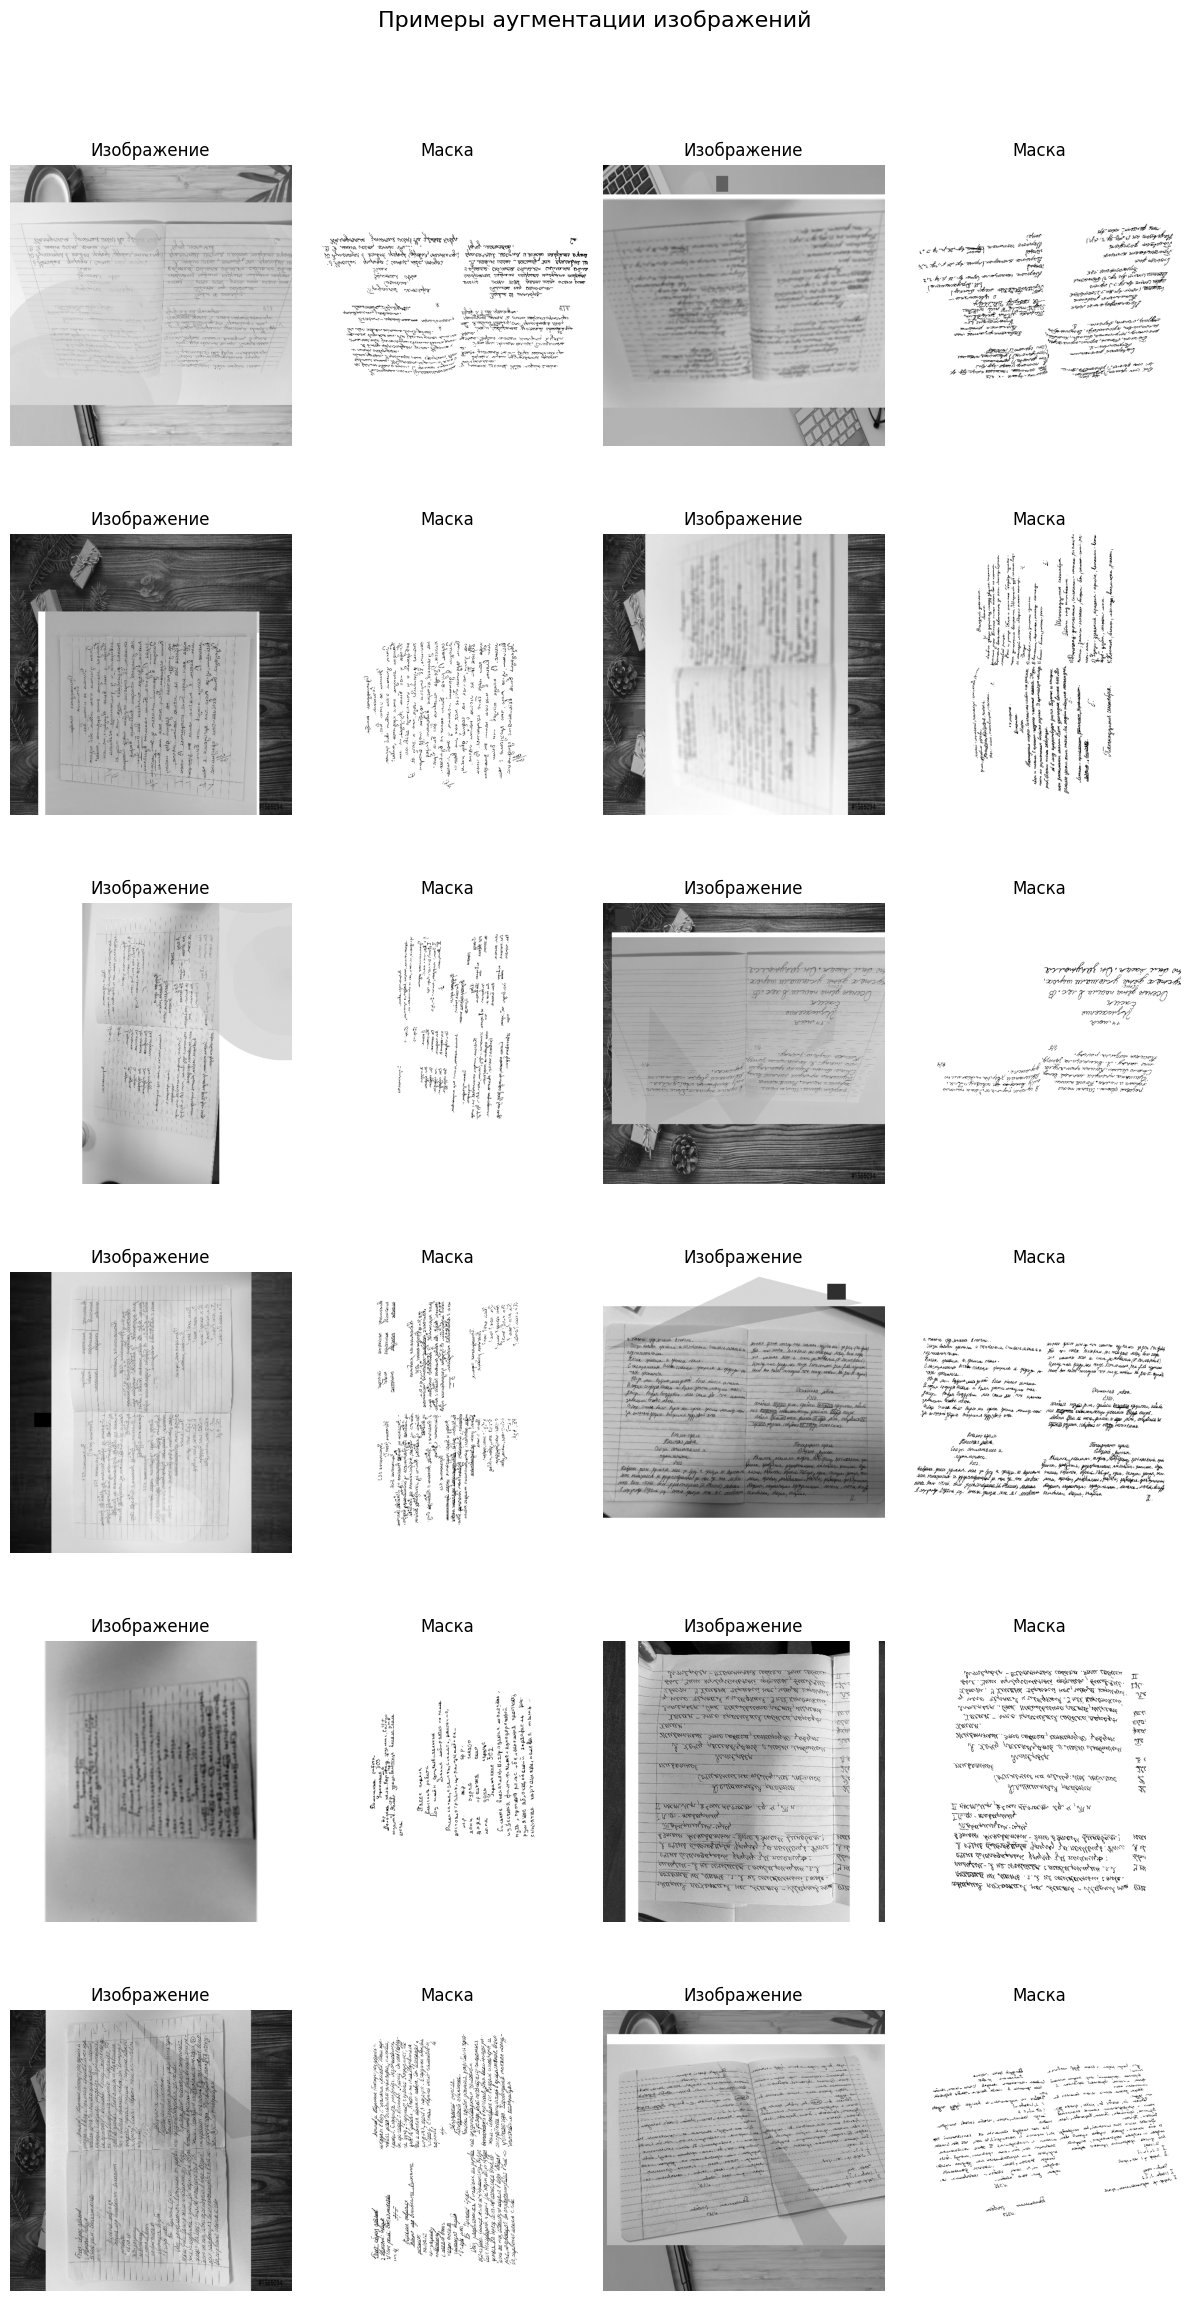

Изображение сохранено как: binarization_examples.png


In [92]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import FileLink

images_dir = "/kaggle/input/datasets/bobrzol123/images-base/images_base"
masks_dir = "/kaggle/input/datasets/bobrzol123/images-binary/images_binary"
target_size = (640, 640)   # если всё равно OOM — уменьши до (2048, 2048)


params_step_1 = {"Affine + HorizontalFlip" : 0, "RandomRotate90 + HorizontalFlip" : 1}
params_step_2 = {"All image" : 1, "Divide into 4 squares" : 0, "All image + Divide into 4 squares" : 0}
dataset = BinarizationDataset(images_dir, masks_dir, target_size=target_size, params_step_1=params_step_1,
                              params_step_2=params_step_2)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

def denormalize(image_tensor):
    """Преобразует нормализованное изображение [-1, 1] -> [0, 1] для отображения"""
    return (image_tensor + 1) / 2

def save_examples(dataset, num_examples=6, cols=2, filename="dataset_examples.png"):
    """Сохраняет примеры в файл и предлагает скачать"""
    rows = (num_examples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 6, rows * 4))
    
    indices = np.random.choice(len(dataset), num_examples, replace=False)
    
    for i, idx in enumerate(indices):
        image_tensor, mask_tensor = dataset[idx]
        
        image = denormalize(image_tensor).squeeze(0).numpy()
        mask = mask_tensor.squeeze(0).numpy()
        
        row = i // cols
        col = (i % cols) * 2
        
        # Изображение
        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title('Изображение')
        axes[row, col].axis('off')
        
        # Маска
        axes[row, col + 1].imshow(mask, cmap='gray', vmin=0, vmax=1)
        axes[row, col + 1].set_title('Маска')
        axes[row, col + 1].axis('off')
    
    plt.suptitle('Примеры аугментации изображений', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Сохраняем в файл
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Изображение сохранено как: {filename}")
    
    # Создаём ссылку для скачивания в Kaggle
    return FileLink(filename)

# Использование:
saved_file = save_examples(train_dataset, num_examples=12, cols=2, filename="binarization_examples.png")

### Загрузка датасета, создание модели

In [93]:
images_dir = "/kaggle/input/datasets/bobrzol123/images-base/images_base"
masks_dir = "/kaggle/input/datasets/bobrzol123/images-binary/images_binary"
target_size = (640, 640)


all_filenames = [
    f for f in os.listdir(images_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG'))
]

# Разделяем на train (90%) и val (10%) с фиксированным random_state для воспроизводимости
train_files, val_files = train_test_split(
    all_filenames, 
    test_size=0.1, 
    random_state=42
)

# Создаём датасеты
train_dataset = BinarizationDataset(
    images_dir, masks_dir, 
    target_size=target_size, 
    augment=True,
    filenames=train_files
)

val_dataset = BinarizationDataset(
    images_dir, masks_dir, 
    target_size=target_size, 
    augment=False,
    filenames=val_files
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")


model = UNetTiny(in_channels=1, out_channels=1)

# Оборачиваем в DataParallel если GPU > 1
if num_gpus > 1:
    model = nn.DataParallel(model)
    print(f"DataParallel включён на {num_gpus} GPU")

model = model.to(device)

def compute_pos_weight(dataset):
    total_white = 0
    total_black = 0
    for i in tqdm(range(len(dataset)), desc="Сompute_pos_weight"):
        _, mask = dataset[i]
        total_black += (mask == 0).sum().item()
        total_white += (mask == 1).sum().item()
    return torch.tensor([total_white / max(total_black, 1)])

# После создания dataset
#pos_weight = compute_pos_weight(train_dataset).to(device) #[28.3598] - вышло

pos_weight = torch.tensor([5]).to(device) # было расчитаны выше 27.4674
print('Соотношение между классами', pos_weight)

Train: 1671, Val: 186
DataParallel включён на 2 GPU
Соотношение между классами tensor([5], device='cuda:0')


### Обучения модели

In [94]:
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # pos_weight=pos_weight

optimizer = optim.Adam

writer = SummaryWriter('./runs/unet_binarization')
batch_size = 16
callback = UNetCallback(writer, val_dataset, loss_function, delimiter=200, batch_size=batch_size)

accumulation_steps = 1

In [95]:
# Обучение
trainer(
    count_of_epoch=10,
    batch_size=batch_size,
    dataset=train_dataset,
    model=model,
    loss_function=loss_function,
    optimizer=optimizer,
    lr=0.0005,
    accumulation_steps=accumulation_steps,
    callback=callback
)

epoch:  70%|███████   | 7/10 [34:52<14:56, 298.95s/it, train epoch loss=0.606]


KeyboardInterrupt: 

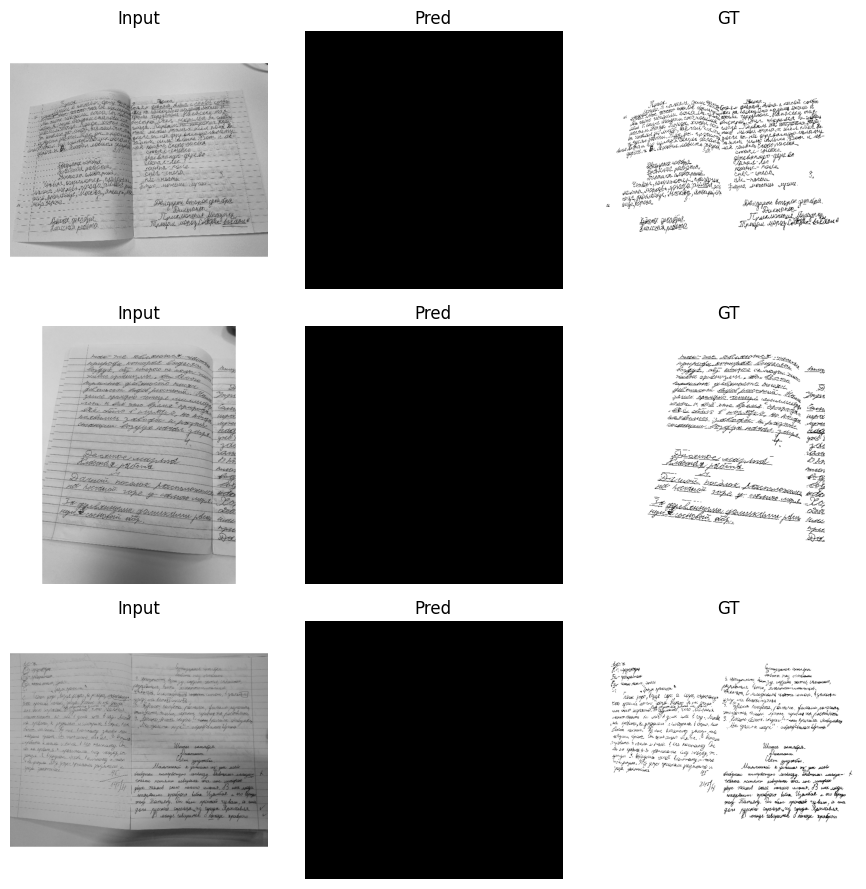

In [96]:
# Берём 3 примера из валидационного датасета (без аугментаций)
model.eval()
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

with torch.no_grad():
    for i in range(3):
        x, y = val_dataset[i]
        x = x.unsqueeze(0).to(device)           # (1,1,H,W)
        y = y.squeeze(0).cpu().numpy()          # (H,W)
        
        logits = model(x)
        prob = torch.sigmoid(logits).squeeze().cpu().numpy()
        pred = (prob > 0.5).astype(np.uint8) * 255
        
        # Входное изображение (денормализуем из [-1,1] в [0,255])
        img = ((x.squeeze().cpu().numpy() + 1) / 2 * 255).astype(np.uint8)
        
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title('Input')
        axes[i, 1].imshow(pred, cmap='gray')
        axes[i, 1].set_title('Pred')
        axes[i, 2].imshow(y, cmap='gray')
        axes[i, 2].set_title('GT')
        for j in range(3):
            axes[i, j].axis('off')
plt.tight_layout()
plt.savefig('примеры работы нейросети', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Сохранение (учитываем DataParallel)
if isinstance(model, nn.DataParallel):
    torch.save(model.module.state_dict(), "unet_binarization_end.pth")
else:
    torch.save(model.state_dict(), "unet_binarization_end.pth")

writer.close()
print("Training finished.")